In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf

In [29]:
start = dt.datetime(2021, 7, 1)
end = dt.datetime(2022, 1, 27)

symbol = "INFY.NS"
stk_data = yf.download(symbol, start=start, end=end)
stk_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2021-07-01,1359.065552,1373.393007,1357.889760,1373.393007,4814317
2021-07-02,1365.510620,1366.947640,1343.562051,1357.802429,5166064
2021-07-05,1375.221924,1380.491350,1359.631602,1366.686458,4058338
2021-07-06,1360.633179,1382.015596,1356.191240,1370.649362,4089574
2021-07-07,1362.723511,1367.905861,1345.347652,1363.986485,4797120


In [30]:
stk_data = stk_data[["Open","High","Low","Close"]]

dataset = stk_data.copy()
stk_data.head()

Price,Open,High,Low,Close
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,
2021-07-01,1373.393007,1373.393007,1357.889760,1359.065552
2021-07-02,1357.802429,1366.947640,1343.562051,1365.510620
2021-07-05,1366.686458,1380.491350,1359.631602,1375.221924
2021-07-06,1370.649362,1382.015596,1356.191240,1360.633179
2021-07-07,1363.986485,1367.905861,1345.347652,1362.723511


In [31]:
features = ["Open","High","Low","Close"]

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(stk_data[features])
print("Dataset Shape :", scaled_data.shape)

Dataset Shape : (143, 4)


In [33]:
scaled_data = pd.DataFrame(scaled_data,columns=features)
scaled_data.head()

,Open,High,Low,Close
0,0.092351,0.057253,0.061133,0.045062
1,0.049469,0.039563,0.021384,0.062893
2,0.073904,0.076736,0.065965,0.089761
3,0.084804,0.080919,0.056420,0.049399
4,0.066478,0.042193,0.026338,0.055182


In [34]:
train_size = int(len(scaled_data) * 0.80)

X_train = scaled_data[:train_size]
X_test = scaled_data[train_size:]

print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

Training : (114, 4)
Testing  : (29, 4)


In [35]:
performance = {"Variables": [],"Lag": [],"RMSE": [],"MAPE": []}

In [36]:
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

def run_var(dataset, columns):
    print("Variables :", columns)
    df = dataset[columns]
    test_size = 28
    train = df[:-test_size]
    test = df[-test_size:]
    model = VAR(train)
    selected = model.select_order(12)
    lag = selected.selected_orders["aic"]
    result = model.fit(lag)
    forecast = result.forecast(train.values[-lag:],steps=test_size)

    forecast_df = pd.DataFrame(forecast,columns=columns)

    rmse = np.sqrt(mean_squared_error(test,forecast))
    mape = mean_absolute_percentage_error(test,forecast)

    performance["Variables"].append(",".join(columns))
    performance["Lag"].append(lag)
    performance["RMSE"].append(rmse)
    performance["MAPE"].append(mape)
    return (pd.DataFrame(performance),result,forecast_df,test)

In [37]:
selected_columns = ["Close","High","Open","Low"]

In [38]:
performance_df, model, prediction, actual = run_var(scaled_data,selected_columns)
prediction.head()

Variables : ['Close', 'High', 'Open', 'Low']


,Close,High,Open,Low
0,0.588027,0.598211,0.603120,0.574230
1,0.582146,0.598188,0.597772,0.563904
2,0.575409,0.593783,0.591610,0.556458
3,0.568778,0.587512,0.584798,0.549536
4,0.562420,0.581031,0.578171,0.543125


In [39]:
performance_df

,Variables,Lag,RMSE,MAPE
0,"Close,High,Open,Low",1,0.292296,0.31684


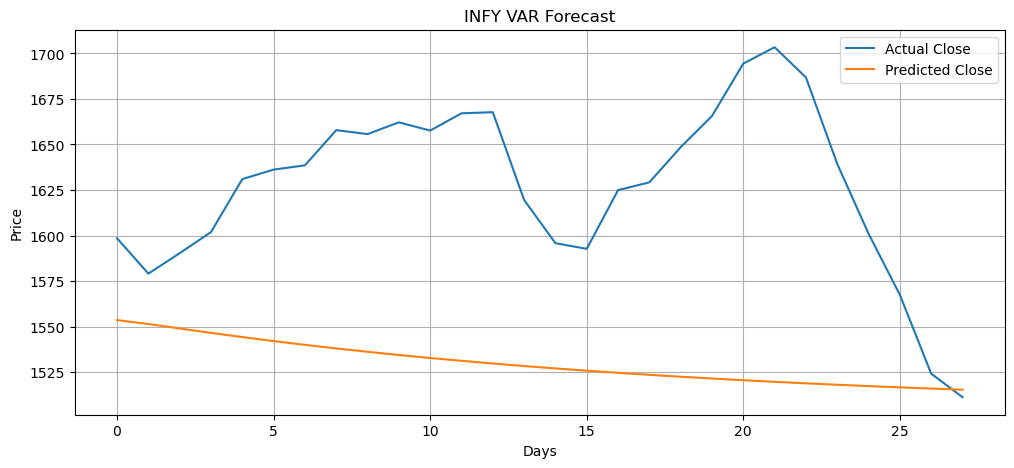

Forecast saved successfully.


In [40]:
prediction_original = pd.DataFrame(scaler.inverse_transform(prediction),columns=selected_columns)
actual_original = pd.DataFrame(scaler.inverse_transform(actual),columns=selected_columns)

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(actual_original["Close"].values,label="Actual Close")

plt.plot(prediction_original["Close"].values,label="Predicted Close")

plt.title("INFY VAR Forecast")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()

prediction_original.to_csv("INFY_VAR_Forecast.csv",index=False)

print("Forecast saved successfully.")